# Problem 3, Homework 2

## Import Packages

We'll need numpy for storing our results, scipy for integration, and matplotlib for plotting.

In [1]:
import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt

## Monte Carlo for a Two-Level System

Consider a two-level atom with ground state $|g\rangle$ and excited state $|e\rangle$. Let the excited state have a decay time of $\Gamma$. Define the eigenvectors as 

$$ |g\rangle = \begin{bmatrix}1\\ 0\end{bmatrix}, |e\rangle = \begin{bmatrix}0\\ 1\end{bmatrix} $$

so that a general wavefunction is represented as 

$$ |\Psi\rangle = \begin{bmatrix}\alpha\\ \beta\end{bmatrix}.$$

Your task is to do the following:

Write a function that evolves the wavefunction a finite amount of time. I have already written an existing function that evolves it an infinitesimal amount of time dt (see below). Then, for the initial states

a) $|\Psi\rangle = \begin{bmatrix}0\\ 1\end{bmatrix}$, i.e. the excited state, and

b) $|\Psi\rangle = \dfrac{1}{\sqrt{2}} \begin{bmatrix}1\\ 1\end{bmatrix}$, i.e. a superposition state,

plot 5 realizations (i.e. 5 different trajectories) of the wavefunction evolution. On each plot, you should have two curves, one the probability of observing the ground state and the other the probability of observing the excited state upon making a measurement, as a function of time. Then plot the average trajectory over 500 realizations. Does it look like exponential decay?

Finally, plot one realization corresponding to $|\Psi\rangle = \begin{bmatrix}1\\ 0\end{bmatrix}$.

Take $\Gamma = 5$.

Here we define the relevant functions:

The function normalize normalizes your wavefunction, if you don't enter it in already normalized.

The function evolve_wavefunction_dt evolves your wavefunction by a small amount from $t_{old}$ to $t_{new}$. It draws a random number from $0$ to $1$. If the number is below the transition probability for that amount of time, the atom will emit a photon and drop to the lowest energy state. If not, the atom will continue to evolve.

In [2]:
def normalize(wf):
    normalization = np.sqrt(wf[0]**2 + wf[1]**2)
    return wf/normalization

def evolve_wavefunction_dt(wf_init,wf,Gamma,t_old,t_new):
    '''
    Feed this function in the following:
    
    wf_init: Your initial wavefunction (specified in the problem).
    wf: The wavefunction at the old time t_old. This will be evolved.
    Gamma: The decay rate, given in the problem.
    t_old: the old time.
    t_new: the new time, t_old + a small time interval.
    '''
    
    # Obtain the parameters required for the rest of the evolution
    # from the input.
    alpha_0 = wf_init[0]
    beta_0 = wf_init[1]
    alpha_old = wf[0]
    beta_old = wf[1]
    
    if beta_old == 0:
        # We are already in lowest energy state
        # No evolution required.
        return wf
    else:
        # Compute the decay probability in this small interval of time tnew-told.
        dp = Gamma*abs(beta_old)**2*(t_new-t_old)
        # Draw a random number from 0 to 1.
        epsilon = np.random.random()
        
        # If the number is small enough, convert to the lowest energy state.
        if dp > epsilon:
            # Photon emitted
            # Convert to lowest energy state.
            wf = np.array([1,0])
            return wf
        # If it isn't, don't emit a photon
        # Instead, evolve the wavefunction.
        else:
            # Compute the new alpha and beta
            # Return the normalized wavefunction.
            alpha_new = alpha_0/np.sqrt(abs(alpha_0)**2+abs(beta_0)**2*np.exp(-Gamma*t_new))
            beta_new = beta_0*np.exp(-Gamma*t_new/2)/np.sqrt(abs(alpha_0)**2+abs(beta_0)**2*np.exp(-Gamma*t_new))
            wf = normalize(np.array([alpha_new,beta_new]))
            return wf

# --- Defines a function that evolves the wavefunction a finite length of time ---
def evolve_wavefunction_finite(wf_init, dt, t_arr, Gamma):
    # Start from the initial wavefunction
    wf = wf_init.copy()

    # List to store the wavefunction at each timestep
    wf_history = []

    # Loop over all time points in the time array
    for i in range(len(t_arr)):

        # Define the previous and current times
        t_old = t_arr[i-1] if i > 0 else 0
        t_new = t_arr[i]

        # Evolve the wavefunction from t_old to t_new
        wf = evolve_wavefunction_dt(wf_init, wf, Gamma, t_old, t_new)

        # Store a copy of the current wavefunction
        wf_history.append(wf.copy())

    # Return the full wavefunction trajectory
    return np.array(wf_history)

# --- Function that evolves N wavefunctions and averages the probabilities ---
def average_over_realizations(Psi_init, dt, t_arr, Gamma, N_realizations=500):
  
    # Arrays to accumulate probabilities
    P_g_sum = np.zeros(len(t_arr))
    P_e_sum = np.zeros(len(t_arr))
    
    # Loop over all realizations
    for _ in range(N_realizations):
        wf_hist = evolve_wavefunction_finite(Psi_init, dt, t_arr, Gamma)
        P_g_sum += abs(wf_hist[:,0])**2
        P_e_sum += abs(wf_hist[:,1])**2
    
    # Average
    P_g_avg = P_g_sum / N_realizations
    P_e_avg = P_e_sum / N_realizations
    
    return P_g_avg, P_e_avg

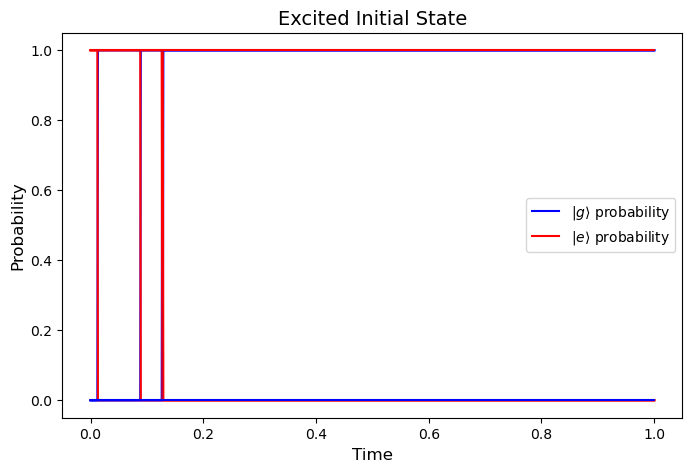

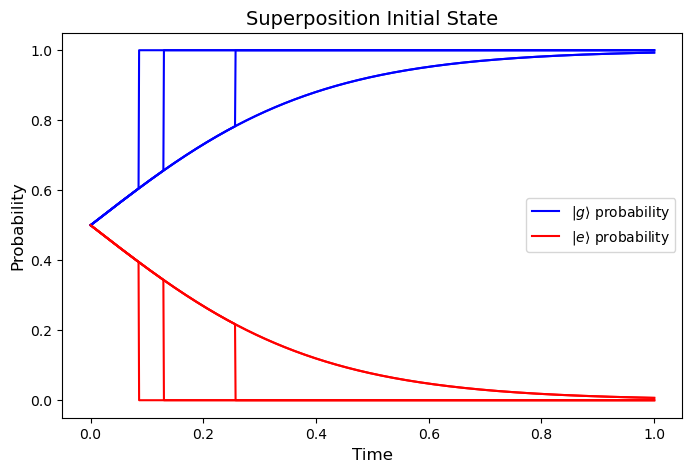

In [7]:
# Define some variables
Gamma = 5 # The decay rate
dt = .001 # The time jump
t = Gamma/5. # The final time
t_arr = np.linspace(0,t,int(t/dt)) # The values of t you may wish to use
N = 500 # The number of realizations to average over

# Initial states
Psi_e = normalize(np.array([0, 1]))
Psi_super = normalize(np.array([1, 1]))

# Function to plot multiple realizations
def plot_realizations(Psi_init, title):
    plt.figure(figsize=(8,5))
    for _ in range(5):
        wf_hist = evolve_wavefunction_finite(Psi_init, dt, t_arr, Gamma)
        P_g = abs(wf_hist[:,0])**2
        P_e = abs(wf_hist[:,1])**2
        plt.plot(t_arr, P_g, 'b', label=r'$|g\rangle$ probability' if _==0 else "")
        plt.plot(t_arr, P_e, 'r', label=r'$|e\rangle$ probability' if _==0 else "")
    plt.xlabel('Time', fontsize=12)
    plt.ylabel('Probability', fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend()
    plt.show()

# Plot for excited initial state
plot_realizations(Psi_e, "Excited Initial State")

# Plot for superposition initial state
plot_realizations(Psi_super, "Superposition Initial State")

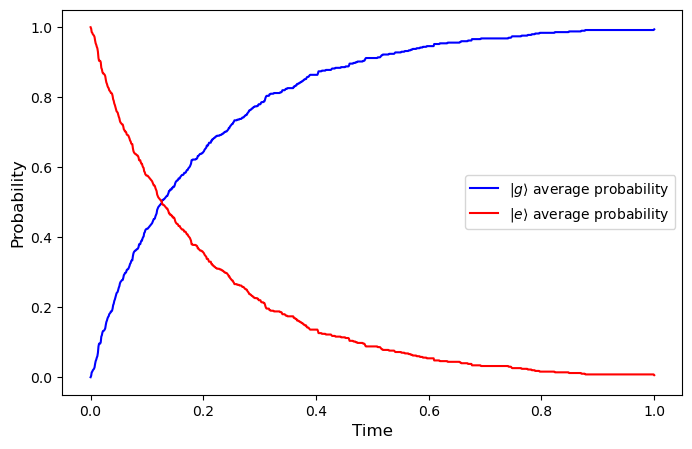

In [8]:
# Average over 500 realizations for the initial state being the excited state
P_g_avg, P_e_avg = average_over_realizations(Psi_e, dt, t_arr, Gamma)

# Plot the data
plt.figure(figsize=(8,5))
plt.plot(t_arr, P_g_avg, 'b', label=r'$|g\rangle$ average probability')
plt.plot(t_arr, P_e_avg, 'r', label=r'$|e\rangle$ average probability')
plt.xlabel('Time', fontsize=12)
plt.ylabel('Probability', fontsize=12)
plt.legend()
plt.show()

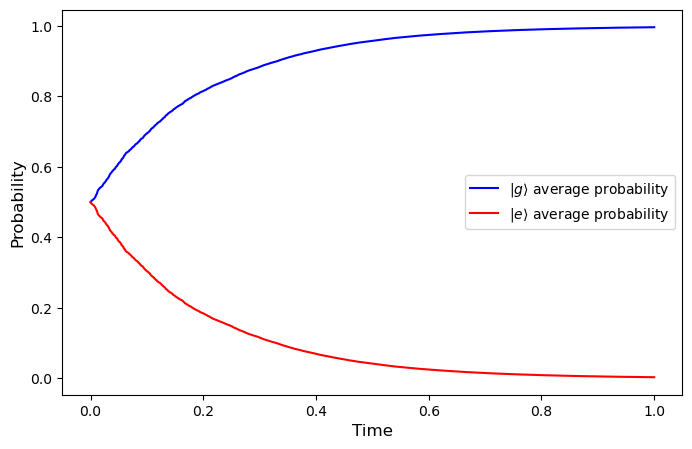

In [9]:
# Average over 500 realizations for the initial state being a superposition of both states
P_g_avg, P_e_avg = average_over_realizations(Psi_super, dt, t_arr, Gamma)

# Plot the data
plt.figure(figsize=(8,5))
plt.plot(t_arr, P_g_avg, 'b', label=r'$|g\rangle$ average probability')
plt.plot(t_arr, P_e_avg, 'r', label=r'$|e\rangle$ average probability')
plt.xlabel('Time', fontsize=12)
plt.ylabel('Probability', fontsize=12)
plt.legend()
plt.show()

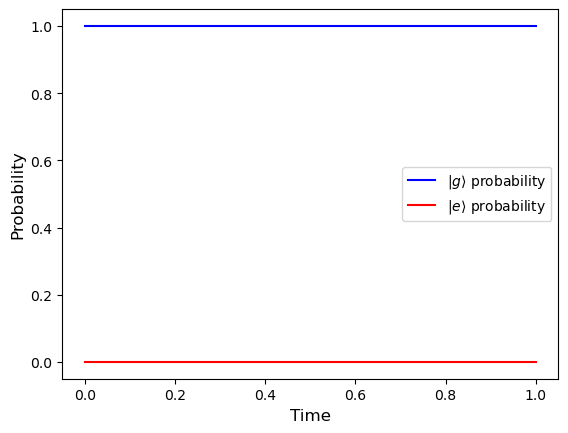

In [10]:
# Create an initial wavefunction in the ground state and evolve it
psi_init_gnd = normalize(np.array([1,0]))
data = evolve_wavefunction_finite(psi_init_gnd, dt, t_arr, Gamma)

# Plot the data
P_g = abs(data[:,0])**2
P_e = abs(data[:,1])**2
plt.plot(t_arr, P_g, 'b', label=r'$|g\rangle$ probability')
plt.plot(t_arr, P_e, 'r', label=r'$|e\rangle$ probability')
plt.xlabel('Time', fontsize=12)
plt.ylabel('Probability', fontsize=12)
plt.legend()
plt.show()